# Gromov--Wasserstein Correspondences Under Deformation

This notebook generates `fig:gromov-isometry-matching`.  GW compares intrinsic pairwise distances, so the ambient position of the two clouds is irrelevant.  We progressively deform the target metric shape, with the last panel using a deliberately strong non-isometric warp.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from matplotlib.collections import LineCollection
import ot
from scipy.spatial.distance import cdist

rng = np.random.default_rng(2027)

NAME = "gromov-isometry-matching"
out = figure_dir(NAME)

In [2]:
def base_shape(n=18):
    t = np.linspace(0, 1, n)
    x = 0.92 * np.cos(1.55 * np.pi * t) + 0.13 * t
    y = 0.74 * np.sin(1.55 * np.pi * t) - 0.28 * t
    q = np.column_stack([x, y])
    q += 0.014 * rng.normal(size=q.shape)
    return q


def rotate(q, a):
    c, s = np.cos(a), np.sin(a)
    R = np.array([[c, -s], [s, c]])
    return q @ R.T


def gw_plan(x, y):
    C1 = ot.dist(x, x)
    C2 = ot.dist(y, y)
    C1 /= max(C1.max(), 1e-12)
    C2 /= max(C2.max(), 1e-12)
    a = np.ones(len(x)) / len(x)
    b = np.ones(len(y)) / len(y)
    G0 = np.eye(len(x), len(y)) / len(x)
    T = ot.gromov.gromov_wasserstein(C1, C2, a, b, "square_loss", G0=G0, epsilon=1e-3, max_iter=500, tol=1e-10, verbose=False)
    return T, C1, C2


def draw_match(x, y, T, filename):
    xd = x + np.array([-1.25, 0.0])
    yd = y + np.array([1.25, 0.0])
    pairs = [(i, int(np.argmax(T[i])), float(T[i].max())) for i in range(T.shape[0])]
    pts = np.vstack([xd, yd])
    xlim, ylim = padded_limits(pts, pad=0.085)
    fig, ax = plt.subplots(figsize=(2.72, 1.75))
    draw_transport_segments(ax, xd, yd, pairs, color=VIOLET, max_width=0.95, min_width=0.12, alpha_scale=0.46, zorder=1)
    draw_point_clouds(ax, xd, yd, base_size=DIRAC_MARKER_SIZE * 0.68)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.032)
    plt.close(fig)

x = base_shape(18)
y_iso = rotate(x, 0.72) + np.array([0.08, -0.02])
y_mild = rotate(x, 0.72)
y_mild[:, 0] *= 1.18
y_mild[:, 1] *= 0.82
y_mild[9:, 1] -= 0.14

y_strong_base = rotate(x, 0.72)
t = np.linspace(0, 1, len(x))
y_strong = np.empty_like(y_strong_base)
y_strong[:, 0] = 1.88 * y_strong_base[:, 0] + 0.50 * np.sin(3.4 * np.pi * t)
y_strong[:, 1] = 0.34 * y_strong_base[:, 1] + 0.72 * y_strong_base[:, 0] ** 2 - 0.50 * (t > 0.55) + 0.26 * np.cos(2 * np.pi * t)

for y, fn in [(y_iso, "isometric.pdf"), (y_mild, "mild-deformation.pdf"), (y_strong, "strong-deformation.pdf")]:
    T, _, _ = gw_plan(x, y)
    draw_match(x, y, T, fn)

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


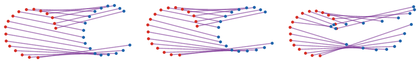

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/gromov-isometry-matching.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/gromov-isometry-matching.png")
display(Image(filename=str(_thumb)))
